# utilities

> Utilities for processing Euclid images.

In [ ]:
# | default_exp euclid.utilities

In [ ]:
# | export

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from astropy.io import fits
from astropy.nddata import block_reduce

from nicl.utilities import compute_pixel_scales
from nicl.euclid.constants import VIS, NISP

In [ ]:
# | hide
# additional imports for examples

from astropy.visualization import ImageNormalize, ZScaleInterval
from matplotlib import pyplot as plt
import matplotlib as mpl

mpl.rc("image", interpolation="none", origin="lower")

In [ ]:
# | export


def get_nisp_images_for_observation(
    obs_id,  # the main observation id
    n_prior=0,  # number of previous observations to include
    n_after=0,  # number of subsequent observations to include
    path=None,  # base path to search
    include_sir=False,  # include SIR files
    fill_missing=True,  # fill missing images with None
):
    """Find NISP images for the specified obs_id and optionally n_prior and n_after observations."""
    info = dict(filename=[], filter=[], dithobs=[], obs_id=[], mjd=[], exptime=[])
    obs_id = int(obs_id)
    path = Path(path)
    for i in range(obs_id - n_prior, obs_id + n_after + 1):
        fns = list(path.glob(f"**/EUC_NIR*-{i}-*Z.fits", recurse_symlinks=True))
        if include_sir:
            sir_fns = list(path.glob(f"**/EUC_SIR*_{i}_*Z.fits", recurse_symlinks=True))
            fns += sir_fns
            n_expected = 16
        else:
            n_expected = 12
        if len(fns) == 0:
            print(f"Found no files for observation id {i}.")
        elif len(fns) < n_expected:
            print(f"Missing some files for observation id {i}.")
            if include_sir and len(sir_fns) == 0:
                print("No SIR files found.")
        elif len(fns) > n_expected:
            print(f"Found too many files for observation id {i}.")
        for fn in fns:
            with fits.open(fn) as f:
                h = f[0].header
                info["filename"].append(fn)
                if include_sir and fn in sir_fns:
                    info["filter"].append("SIR")
                else:
                    info["filter"].append(h["FILTER"])
                info["dithobs"].append(h["DITHOBS"])
                info["obs_id"].append(h["OBS_ID"])
                info["mjd"].append(h["MJD-OBS"])
                info["exptime"].append(h["EXPTIME"])
    info = pd.DataFrame(info)
    info = info.sort_values("mjd").reset_index(drop=True)
    if fill_missing:
        info["obs_id"] = info["obs_id"].astype("Int64")
        obs_ids = info["obs_id"].unique()
        filters = ["J", "H", "Y"]
        if include_sir:
            filters = ["SIR"] + filters
        info = info.set_index(["obs_id", "dithobs", "filter"])
        expected_index = pd.MultiIndex.from_product(
            [obs_ids, range(4), filters], names=["obs_id", "dithobs", "filter"]
        )
        info = info.reindex(expected_index).reset_index()
        info[["mjd", "exptime", "obs_id"]] = info[["mjd", "exptime", "obs_id"]].fillna(
            0
        )
        info["filename"] = info["filename"].fillna("")
    return info

In [ ]:
# | export


def get_primary_header(
    fns,  # an iterable of image filenames
):
    """Create a primary header from the provided list of files.

    The returned header contains all the entries from the files' primary headers
    that have consistent values across all the files.
    """
    hdr = fits.Header()
    mismatch = set()
    for fn in fns:
        if fn:
            newhdr = fits.getheader(fn)
            for h in newhdr:
                if h not in hdr:
                    try:
                        hdr[h] = newhdr[h]
                    except ValueError:
                        pass
                elif hdr[h] != newhdr[h]:
                    mismatch.add(h)
    for h in mismatch:
        hdr.remove(h)
    return hdr

In [ ]:
# | export


def dq_to_mask(dq, maskbits=[0]):
    maskbits = np.atleast_1d(maskbits)
    mask = dq & 2 ** maskbits[0] > 0
    for b in maskbits[1:]:
        mask |= dq & 2**b > 0
    return mask


def get_dq_mask(fn, extname="SCI", maskbits=[0], instrument="NIR"):
    dq_suffix = "FLG" if instrument == "VIS" else "DQ"
    extname = extname.replace("SCI", dq_suffix)
    dq = fits.getdata(fn, extname=extname)
    return dq_to_mask(dq, maskbits)


def get_persistence_mask(fn, extname):
    return get_dq_mask(fn, extname, [13])


def get_invalid_mask(fn, extname):
    if fn:
        return get_dq_mask(fn, extname, [0])


def get_invalid_mask_without_persistence(fn, extname):
    if fn:
        return get_dq_mask(fn, extname, [2, 3, 4, 6, 7, 8, 9, 10, 16, 23])


def get_nir_saturation_only_mask(fn, extname):
    sat = get_dq_mask(fn, extname, [10])
    otherwise_invalid = get_dq_mask(fn, extname, [2, 3, 4, 6, 7, 8, 9, 13, 16, 23])
    return sat & ~otherwise_invalid


def get_vis_star_mask(fn, extname):
    return get_dq_mask(fn, extname, [18], instrument="VIS")


def get_rms(fn, extname, instrument="NIR"):
    rms_suffix = "RMS" if instrument == "NIR" else "VAR"
    extname = extname.replace("SCI", rms_suffix)
    rms = fits.getdata(fn, extname=extname)
    if instrument == "VIS":
        rms = np.sqrt(rms)
    return rms


def fits_append(fn, data, ext, primary_header, exthdr=None):
    if exthdr is None:
        exthdr = fits.Header([("EXTNAME", ext)])
    else:
        exthdr.update(EXTNAME=ext)
    if not os.path.exists(fn):
        fits.append(fn, None, primary_header)
    fits.append(fn, data, exthdr)

In [ ]:
# | export


def remove_if_necessary(path, fnglob):
    fns = Path(path).glob(fnglob)
    for fn in fns:
        os.remove(fn)

In [ ]:
# | export


def default_data_path(*subfolders):
    """Discover the default path to Euclid data, and append `subfolder`.

    This first looks for an environment variable `EUCLID_DATA`. If that is not found,
    it looks for a folder (potentially a link) `~/euclid_data`. If that is not present,
    it raises an error. Finally, any provided subfolders are appended to the path.
    """
    path = os.environ.get("EUCLID_DATA")
    if path is None:
        path = "~/euclid_data"
    path = Path(path).expanduser()
    if not path.is_dir():
        raise FileNotFoundError(f"Folder {path} does not exist.")
    if subfolders:
        path = path / Path(*subfolders)
    return path

In [ ]:
# | export


def euclid_credentials():
    """Get Euclid user and password from `~/.euclid_credentials`, if it exists."""
    fn = Path("~/.euclid_credentials").expanduser()
    if fn.is_file():
        with open(fn) as stream:
            credentials = yaml.safe_load(stream)
        return credentials

In [ ]:
# | export


class TooManyFilesFoundError(Exception):
    pass


def find_single_file(fn, path):
    fns = list(Path(path).glob(f"**/{fn}", recurse_symlinks=True))
    if len(fns) == 0:
        raise FileNotFoundError(f"No files found matching {fn}")
    elif len(fns) > 1:
        raise TooManyFilesFoundError(f"More than one file found matching {fn}")
    return fns[0]


def get_nisp_tile(tile_index, filter, path):
    filter = filter.replace("NIR_", "")
    fn = f"EUC_MER_BGSUB-MOSAIC-NIR-{filter}_TILE{tile_index}*.fits"
    return find_single_file(fn, path)


def get_nisp_dither(obs_id, dither, filter, path):
    filter = filter.replace("NIR_", "")
    fn = f"EUC_NIR_W-CAL-IMAGE_{filter}-{obs_id}-{dither}*.fits"
    return find_single_file(fn, path)


def get_nisp_stack(obs_id, filter, path):
    filter = filter.replace("NIR_", "")
    fn = f"EUC_NIR_W-STK_{filter}-{obs_id}.fits"
    return find_single_file(fn, path)


def get_vis_tile(tile_index, path):
    fn = f"EUC_MER_BGSUB-MOSAIC-VIS_TILE{tile_index}*.fits"
    return find_single_file(fn, path)


def get_vis_dither(obs_id, dither, path):
    obs_id = f"{obs_id:06d}"
    if len(dither) == 3:
        dither = f"0{dither}"
    fn = f"EUC_VIS_SWL-DET-{obs_id}-{dither}*.fits"
    return find_single_file(fn, path)


def get_vis_stack(obs_id, path):
    obs_id = f"{obs_id:06d}"
    fn = f"EUC_VIS_SWL-STK-{obs_id}.fits"
    return find_single_file(fn, path)

## Get information from standard Euclid filename

In [ ]:
# | export


def get_tile_index_from_filename(fn):
    fn = os.path.basename(fn)
    match = re.search(r"TILE(?P<id>(\d)*)[-_.]", fn)
    tile_index = int(match.group("id")) if match else None
    return tile_index


def get_obs_id_from_filename(fn):
    fn = os.path.basename(fn)
    match = re.search(r"[-_](?P<id>(\d)*)[-_.]", fn)
    obs_id = match.group("id") if match else None
    obs_id = int(obs_id) if obs_id else None
    return obs_id


def get_dither_id_from_filename(fn):
    fn = os.path.basename(fn)
    match = re.search(r"VIS.*[-_]0?(?P<id>\d-\d)[-_.]", fn)
    if match is None:
        match = re.search(r"[-_](?P<id>\d)[-_.]", fn)
    dither_id = match.group("id") if match else None
    return dither_id


def get_filter_from_filename(fn):
    fn = os.path.basename(fn)
    match = re.search(r"_(?P<filter>(VIS|SIR))[-_]", fn)
    if match is None:
        match = re.search(r"[-_]NIR.*[-_](?P<filter>[YJH])[-_]", fn)
    filter = match.group("filter") if match else None
    return filter

## Math

In [ ]:
# | export


def round_up_box_size(x, y):
    """Return an integer z closest to y that approximate integer * z = x."""
    if not isinstance(x, int) or x < 0:
        raise ValueError("x must be a positive integer")
    if y > x:
        return x
    if y <= 1:
        return 1
    if x % round(y) == 0:
        return round(y)
    frac_upper = np.round(x / np.floor(x / y)).astype(int)
    frac_lower = np.round(x / np.ceil(x / y)).astype(int)
    if np.abs(frac_upper - y) < np.abs(frac_lower - y):
        z = frac_upper
    else:
        z = frac_lower
    # check if z actually reduces the padding/cropping compared to round(y)
    if np.min([x % z, z - (x % z)]) > np.min([x % round(y), round(y) - (x % round(y))]):
        raise ValueError("This should not happen")
    return z

## Plotting

In [ ]:
# | export


def assemble_fpa_mosaic(
    hdus, instrument="NISP", binsize=None, unify_zpt=None, unify_pix_scl=None
):
    """Assemble the focal plane mosaic image from a multi-extension FITS file.

    Parameters
    ----------
    hdus : astropy.io.fits.HDUList
        The HDUs from a FITS file, where each extension contains the data of one detector.
    instrument : str, optional
        Instrument name, either "NISP" or "VIS". Default is "NISP".
    binsize : int, optional
        If provided, bin the final mosaic image by this factor using median combining.
    unify_zpt : float, optional
        If provided, scale all detector images to a common magnitude zero point.
    unify_pix_scl : float, optional
        If provided, scale all pixel values to a common pixel scale. Use caution with this
        option, as it can significantly slow down the processing.

    Returns
    -------
    np.ndarray
        A 2D numpy array representing the assembled focal plane mosaic image. Gaps between
        detectors are filled with NaN values.

    """
    inst = NISP if instrument == "NISP" else VIS
    if instrument == "NISP":
        zpt_key = "ZPAB"
    else:
        zpt_key = "MAGZEROP"
    chips = inst.chip_layout
    pixel_scale = inst.pix_scale
    gap_x = inst.gaps[0]
    gap_y = inst.gaps[1]
    gap_x_pixels = np.round(np.array(gap_x) / pixel_scale).astype(int)
    gap_y_pixels = np.round(np.array(gap_y) / pixel_scale).astype(int)
    # broadcast the gaps array to match number of chips in both dimensions
    gap_x_pixels = np.resize(gap_x_pixels, chips.shape[1])
    gap_y_pixels = np.resize(gap_y_pixels, chips.shape[0])
    # set the gap for the last row/column to 0
    gap_x_pixels[-1] = 0
    gap_y_pixels[-1] = 0
    imgs_all_rows = []
    for chip_row, gap_y in zip(chips, gap_y_pixels):
        imgs_per_row = []
        for chip, gap_x in zip(chip_row, gap_x_pixels):
            chip = str(chip)
            img = hdus[chip + ".SCI"].data
            # NISP DET[34][*] are rotated by 180 degrees;
            # VIS rotation already embodied in chip layout (EFGH arrangement)
            if instrument == "NISP":
                if int(chip[3]) > 2:
                    img = img[::-1, ::-1]
            if unify_zpt is not None:
                unify_zpt = float(unify_zpt)
                zpt = hdus[chip + ".SCI"].header[zpt_key]
                img = img * 10 ** ((unify_zpt - zpt) / 2.5)
            if unify_pix_scl is not None:
                unify_pix_scl = float(unify_pix_scl)
                eff_pix_scl = compute_pixel_scales(hdus[chip + ".SCI"].header)
                img = img * (unify_pix_scl / eff_pix_scl) ** 2
            # pad the image with NaNs
            img = np.pad(
                img, ((0, gap_y), (0, gap_x)), mode="constant", constant_values=np.nan
            )
            imgs_per_row.append(img)
        mosaic_per_row = np.concatenate(imgs_per_row, axis=1)
        imgs_all_rows.append(mosaic_per_row)
    mosaic = np.concatenate(imgs_all_rows, axis=0)
    # optionally bin the mosaic
    if binsize is not None:
        binsize = np.round(binsize).astype(int)
        mosaic = block_reduce(mosaic, binsize, np.median)
    return mosaic

### Tests

In [ ]:
def test_get_obs_id_from_filename():
    fns = [
        "EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
        "EUC_VIS_SWL-DET-002683-01-2-0000000__20241017T024939.257987Z.fits",
        "EUC_SIR_W-SCIFRM_BKGSUB_2683_11838_1_RGS180_4_2024-10-31T17:46:48.124158Z.fits",
        "this/that/a-1234-b/EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
        "EUC_NIR_J-2683.fits",
        "EUC_VIS-2683.fits",
    ]
    for fn in fns:
        obs_id = get_obs_id_from_filename(fn)
        assert obs_id == 2683


test_get_obs_id_from_filename()

In [ ]:
def test_get_dither_id_from_filename():
    fns = [
        "EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
        "EUC_SIR_W-SCIFRM_BKGSUB_2683_11838_1_RGS180_4_2024-10-31T17:46:48.124158Z.fits",
        "this/that/a-1234-b/EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
    ]
    for fn in fns:
        dither_id = get_dither_id_from_filename(fn)
        assert dither_id == "1"
    fns = [
        "EUC_VIS_SWL-DET-002683-01-2-0000000__20241017T024939.257987Z.fits",
        "this/that/a-1234-b/EUC_VIS_SWL-DET-002683-01-2-0000000__20241017T024939.257987Z.fits",
    ]
    for fn in fns:
        dither_id = get_dither_id_from_filename(fn)
        assert dither_id == "1-2"
    fns = [
        "EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
        "this/that/TILE1234-b/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
        "EUC_NIR_J-2683.fits",
        "EUC_VIS-2683.fits",
    ]
    for fn in fns:
        dither_id = get_dither_id_from_filename(fn)
        assert dither_id is None


test_get_dither_id_from_filename()

In [ ]:
def test_get_filter_from_filename():
    fns = [
        "EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
        "EUC_VIS_SWL-DET-002683-01-2-0000000__20241017T024939.257987Z.fits",
        "EUC_SIR_W-SCIFRM_BKGSUB_2683_11838_1_RGS180_4_2024-10-31T17:46:48.124158Z.fits",
        "this/that/a-1234-b/EUC_NIR_W-CAL-IMAGE_J-2683-1_20240930T172941.702020Z.fits",
        "EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
        "this/that/TILE1234-b/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
        "EUC_NIR_J-2683.fits",
        "EUC_VIS-2683.fits",
    ]
    filters = [get_filter_from_filename(fn) for fn in fns]
    assert filters == ["J", "VIS", "SIR", "J", "H", "H", "J", "VIS"]


test_get_filter_from_filename()

In [ ]:
def test_get_tile_index_from_filename():
    fns = [
        "EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
        "this/that/TILE1234-b/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102018211-42F1AD_20241018T142558.469987Z_00.00.fits",
    ]
    for fn in fns:
        assert get_tile_index_from_filename(fn) == 102018211


test_get_tile_index_from_filename()

## Examples

### assemble a focal plane mosaic image from a Euclid datacube

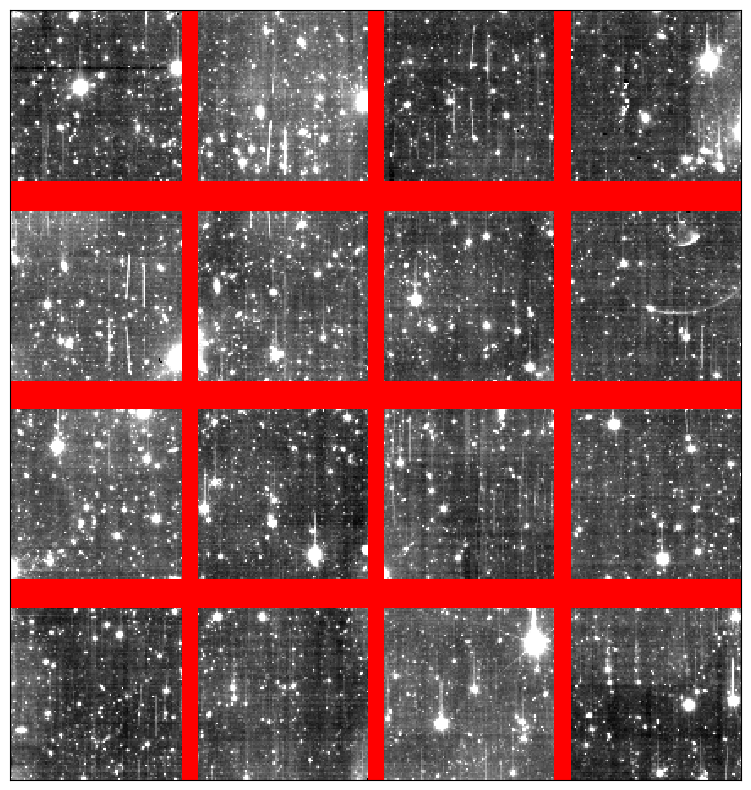

In [ ]:
# NISP example
dither_path = (
    default_data_path("Q1_R1", "NIR", "2683")
    / "EUC_NIR_W-CAL-IMAGE_H-2683-0_20240930T184607.344746Z.fits"
)
# VIS example
# dither_path = (
#     default_data_path("Q1_R1", "VIS_QUAD", "2683")
#     / "EUC_VIS_SWL-DET-002683-00-1-0000000__20241017T024940.664995Z.fits"
# )
with fits.open(dither_path) as hdul:
    fpa = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=20)
    norm = ImageNormalize(fpa, interval=ZScaleInterval())
    cmap = plt.get_cmap("gray")
    cmap.set_bad("red")
    plt.figure(figsize=(10, 10))
    plt.imshow(fpa, cmap=cmap, norm=norm)
    plt.xticks([])
    plt.yticks([])

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()